# Redes Neuronales II — Clasificación Multiclase con MNIST (TensorFlow/Keras y PyTorch)

**Estudiante:** Joan Schneider Beltrán Delgado
**Correo institucional:** jsbeltran@ucundinamarca.edu.co
**Asignatura:** Deep Learning – Conceptos
**Institución:** Universidad de Cundinamarca – Posgrados
**Repositorio GitHub:** https://github.com/JoanBeltranAlt/redes-neuronales-ii

## Tabla de contenido

- **0.** Configuración del entorno y carga del dataset MNIST
- **1.** Exploración y preprocesamiento de los datos
- **2.** Clasificación multiclase con TensorFlow + Keras (red densa, sin CNN)
- **3.** Clasificación multiclase con PyTorch (red densa, sin CNN)
- **4.** Comparación de resultados y evidencias de ejecución
- **5.** Conclusiones

## Objetivo

Hasta ahora habíamos trabajado con problemas de dos clases (clasificación binaria). En este notebook damos el siguiente paso: enfrentar un problema de **clasificación multiclase** sobre datos reales, usando el clásico dataset **MNIST** de dígitos escritos a mano (10 categorías posibles, del 0 al 9).

Pasar de dos clases a diez trae un cambio importante en cómo se arma la red:

- La capa de salida ya no tiene una sola neurona, sino **una por cada clase** (10 en total).
- En lugar de sigmoide, la salida usa **Softmax**, que convierte los valores de la red en algo que se puede leer como "probabilidad de que la imagen sea cada uno de los dígitos" (todas esas probabilidades suman 1).
- El error se mide con la **entropía cruzada categórica**, que es la versión de la binary cross-entropy pensada para más de dos clases.

Construimos la misma arquitectura dos veces —una en **TensorFlow + Keras** y otra en **PyTorch**— para ver cómo resuelve cada framework exactamente el mismo problema.

## Marco conceptual

- **MNIST**: un conjunto clásico de 70,000 imágenes en escala de grises, de 28×28 píxeles cada una, con dígitos manuscritos del 0 al 9. Es prácticamente el ejemplo introductorio obligado cuando se aprende a clasificar imágenes.
- **Softmax**: toma los valores que produce la red para cada clase y los convierte en una distribución de probabilidad válida — es decir, todos positivos y sumando exactamente 1, de modo que se pueden interpretar directamente como "qué tan seguro está el modelo de cada opción".
- **Entropía cruzada categórica**: mide qué tan lejos está la distribución de probabilidad que predijo el modelo de la respuesta correcta. Cuanto más segura y equivocada sea una predicción, mayor es el castigo.
- **Red densa (fully connected) vs. CNN**: en este notebook usamos únicamente capas densas (`Dense` en Keras, `Linear` en PyTorch), lo que implica aplanar cada imagen de 28×28 en un vector de 784 números. No usamos redes convolucionales (CNN), que son las que normalmente se usan para imágenes porque sí aprovechan la estructura 2D — pero eso queda fuera del alcance de esta actividad.


## 0. Configuración del entorno y carga del dataset MNIST

Este notebook está pensado para correr en **Google Colab**. MNIST se descarga solo, usando las utilidades de `tensorflow.keras.datasets` para la parte de Keras y de `torchvision.datasets` para la parte de PyTorch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

I0000 00:00:1790273567.109311  903363 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


NumPy: 2.5.3
TensorFlow: 2.21.0


In [2]:
# Carga del dataset MNIST predefinido (incluido en Keras)
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Imágenes de entrenamiento:", X_train_full.shape)
print("Etiquetas de entrenamiento:", y_train_full.shape)
print("Imágenes de prueba:", X_test.shape)
print("Rango de píxeles:", X_train_full.min(), "-", X_train_full.max())
print("Clases:", np.unique(y_train_full))

Imágenes de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imágenes de prueba: (10000, 28, 28)
Rango de píxeles: 0 - 255
Clases: [0 1 2 3 4 5 6 7 8 9]


## 1. Exploración y preprocesamiento de los datos

Primero echamos un vistazo a algunas imágenes del dataset, y después las preparamos para la red: llevamos los valores de los píxeles al rango [0, 1] (en vez de 0-255) y convertimos cada imagen de 28×28 en un vector de 784 números, ya que una red densa no entiende de "filas y columnas" como sí lo haría una CNN — solo recibe una lista larga de números.

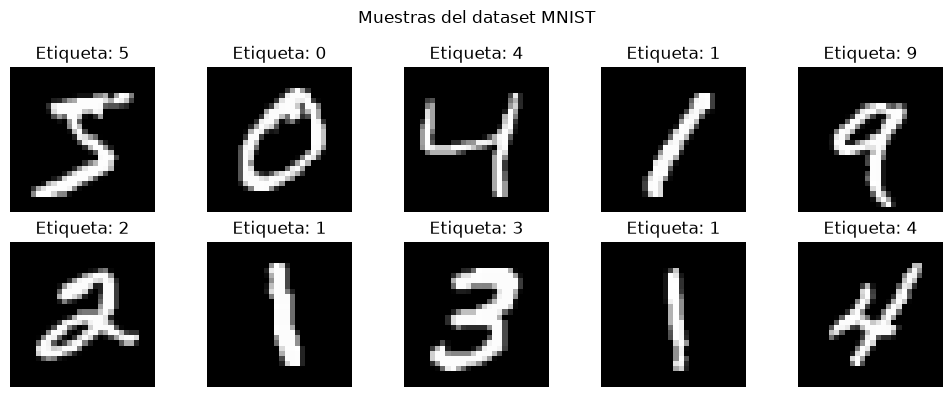

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i], cmap="gray")
    ax.set_title(f"Etiqueta: {y_train_full[i]}")
    ax.axis("off")
plt.suptitle("Muestras del dataset MNIST")
plt.tight_layout()
plt.show()

In [4]:
# Normalización: píxeles de [0, 255] a [0, 1] (acelera y estabiliza el entrenamiento)
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Aplanado: (N, 28, 28) -> (N, 784), ya que usamos capas densas, no convolucionales
X_train_full_flat = X_train_full.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# Separamos un conjunto de validación a partir del set de entrenamiento
n_val = 5000
X_val_flat, X_train_flat = X_train_full_flat[:n_val], X_train_full_flat[n_val:]
y_val, y_train = y_train_full[:n_val], y_train_full[n_val:]

print("Train:", X_train_flat.shape, "| Val:", X_val_flat.shape, "| Test:", X_test_flat.shape)

Train: (55000, 784) | Val: (5000, 784) | Test: (10000, 784)


## 2. Clasificación multiclase con TensorFlow + Keras

Armamos una red con la arquitectura **784 → 128 (ReLU) → 64 (ReLU) → 10 (Softmax)**, sin capas convolucionales. Como las etiquetas vienen como números enteros (0, 1, 2... 9) y no como vectores one-hot, usamos `sparse_categorical_crossentropy` como función de pérdida, que está pensada justo para ese caso.

In [5]:
model_keras_mnist = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")   # 10 clases, una por dígito
])

model_keras_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_keras_mnist.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_keras_mnist = model_keras_mnist.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val_flat, y_val),
    verbose=1
)

Epoch 1/10


W0000 00:00:1790273573.288716  903363 cpu_allocator_impl.cc:82] Allocation of 172480000 exceeds 10% of free system memory.


  1/430 ━━━━━━━━━━━━━━━━━━━━ 5:45 805ms/step - accuracy: 0.0625 - loss: 2.3767

 24/430 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5983 - loss: 1.5359    

 46/430 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7135 - loss: 1.0846

...

346/430 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9941 - loss: 0.0209

369/430 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9942 - loss: 0.0205

392/430 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9943 - loss: 0.0205

416/430 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9944 - loss: 0.0203

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9944 - loss: 0.0202 - val_accuracy: 0.9754 - val_loss: 0.0955



Keras — Exactitud en el conjunto de prueba (evidencia de ejecución): 97.27%


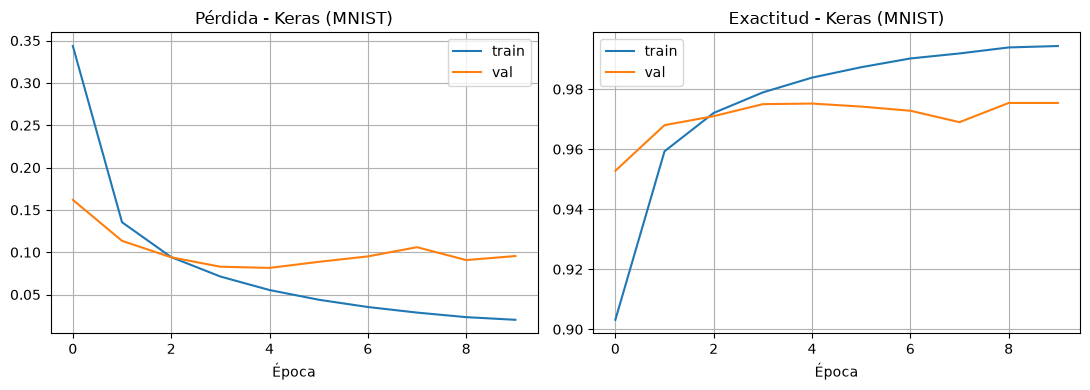

In [7]:
test_loss_keras, test_acc_keras = model_keras_mnist.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nKeras — Exactitud en el conjunto de prueba (evidencia de ejecución): {test_acc_keras*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_keras_mnist.history["loss"], label="train")
axes[0].plot(history_keras_mnist.history["val_loss"], label="val")
axes[0].set_title("Pérdida - Keras (MNIST)")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_keras_mnist.history["accuracy"], label="train")
axes[1].plot(history_keras_mnist.history["val_accuracy"], label="val")
axes[1].set_title("Exactitud - Keras (MNIST)")
axes[1].set_xlabel("Época")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

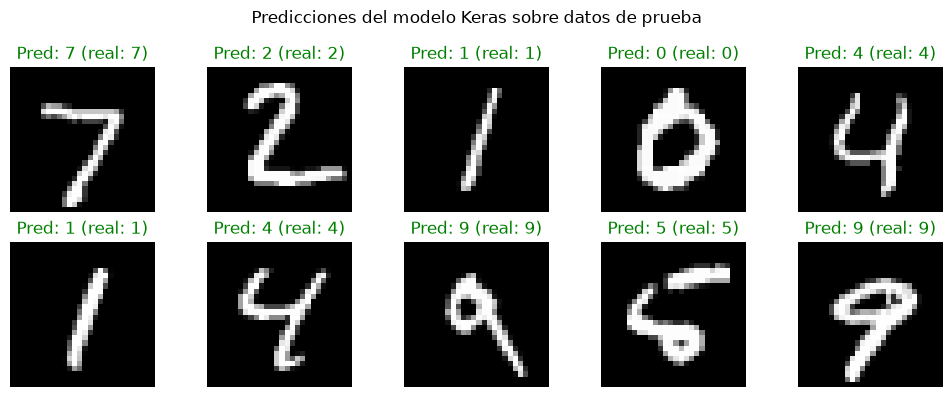

In [8]:
# Evidencia de ejecución: predicciones sobre algunas muestras de prueba
preds_keras = np.argmax(model_keras_mnist.predict(X_test_flat[:10], verbose=0), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap="gray")
    color = "green" if preds_keras[i] == y_test[i] else "red"
    ax.set_title(f"Pred: {preds_keras[i]} (real: {y_test[i]})", color=color)
    ax.axis("off")
plt.suptitle("Predicciones del modelo Keras sobre datos de prueba")
plt.tight_layout()
plt.show()

## 3. Clasificación multiclase con PyTorch

Replicamos la misma arquitectura (**784 → 128 (ReLU) → 64 (ReLU) → 10**) en PyTorch. Aquí hay un detalle que vale la pena mencionar: `nn.CrossEntropyLoss` de PyTorch ya incluye internamente el cálculo de Softmax, así que la red devuelve directamente los valores "crudos" de la última capa (sin aplicar softmax explícitamente) y es la propia función de pérdida la que se encarga de esa conversión.

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

X_train_t = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_flat, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)

print("PyTorch:", torch.__version__)

PyTorch: 2.14.0+cpu


In [10]:
class TorchMNISTClassifier(nn.Module):
    """Red densa multicapa: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10 (logits, sin CNN)."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)   # logits crudos; CrossEntropyLoss aplica softmax internamente
        )

    def forward(self, x):
        return self.net(x)


model_torch_mnist = TorchMNISTClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_torch_mnist.parameters(), lr=0.001)

print(model_torch_mnist)

TorchMNISTClassifier(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [11]:
def evaluate_torch(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean().item()
        loss = criterion(logits, y).item()
    return loss, acc


history_torch_mnist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(10):
    model_torch_mnist.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model_torch_mnist(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate_torch(model_torch_mnist, X_train_t, y_train_t)
    val_loss, val_acc = evaluate_torch(model_torch_mnist, X_val_t, y_val_t)

    history_torch_mnist["loss"].append(train_loss)
    history_torch_mnist["val_loss"].append(val_loss)
    history_torch_mnist["accuracy"].append(train_acc)
    history_torch_mnist["val_accuracy"].append(val_acc)

    print(f"Época {epoch + 1:2d}/10 | loss: {train_loss:.4f} | acc: {train_acc*100:.2f}% "
          f"| val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}%")

Época  1/10 | loss: 0.2235 | acc: 93.37% | val_loss: 0.2150 | val_acc: 93.64%


Época  2/10 | loss: 0.1396 | acc: 95.91% | val_loss: 0.1427 | val_acc: 95.94%


Época  3/10 | loss: 0.1185 | acc: 96.35% | val_loss: 0.1270 | val_acc: 96.26%


Época  4/10 | loss: 0.0788 | acc: 97.69% | val_loss: 0.0970 | val_acc: 97.18%


Época  5/10 | loss: 0.0745 | acc: 97.73% | val_loss: 0.1021 | val_acc: 96.80%


Época  6/10 | loss: 0.0560 | acc: 98.37% | val_loss: 0.0903 | val_acc: 97.48%


Época  7/10 | loss: 0.0395 | acc: 98.85% | val_loss: 0.0745 | val_acc: 97.70%


Época  8/10 | loss: 0.0335 | acc: 99.02% | val_loss: 0.0752 | val_acc: 97.62%


Época  9/10 | loss: 0.0256 | acc: 99.34% | val_loss: 0.0769 | val_acc: 97.76%


Época 10/10 | loss: 0.0249 | acc: 99.26% | val_loss: 0.0789 | val_acc: 97.88%



PyTorch — Exactitud en el conjunto de prueba (evidencia de ejecución): 97.68%


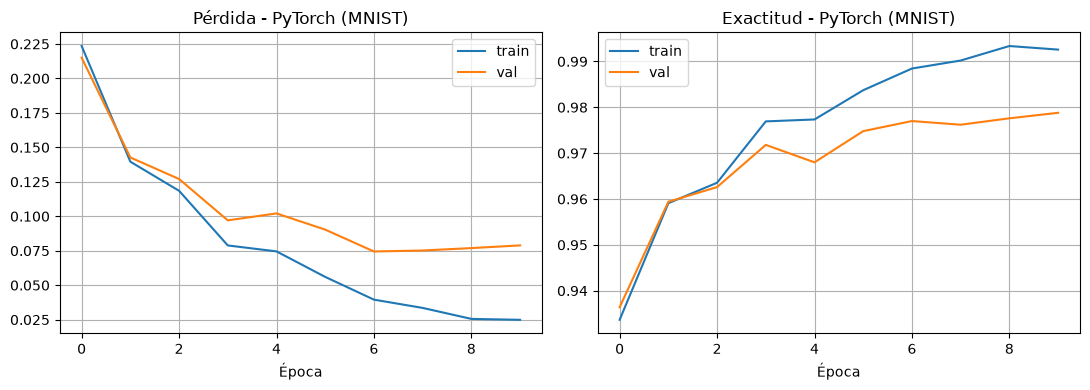

In [12]:
test_loss_torch, test_acc_torch = evaluate_torch(model_torch_mnist, X_test_t, y_test_t)
print(f"\nPyTorch — Exactitud en el conjunto de prueba (evidencia de ejecución): {test_acc_torch*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_torch_mnist["loss"], label="train")
axes[0].plot(history_torch_mnist["val_loss"], label="val")
axes[0].set_title("Pérdida - PyTorch (MNIST)")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_torch_mnist["accuracy"], label="train")
axes[1].plot(history_torch_mnist["val_accuracy"], label="val")
axes[1].set_title("Exactitud - PyTorch (MNIST)")
axes[1].set_xlabel("Época")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

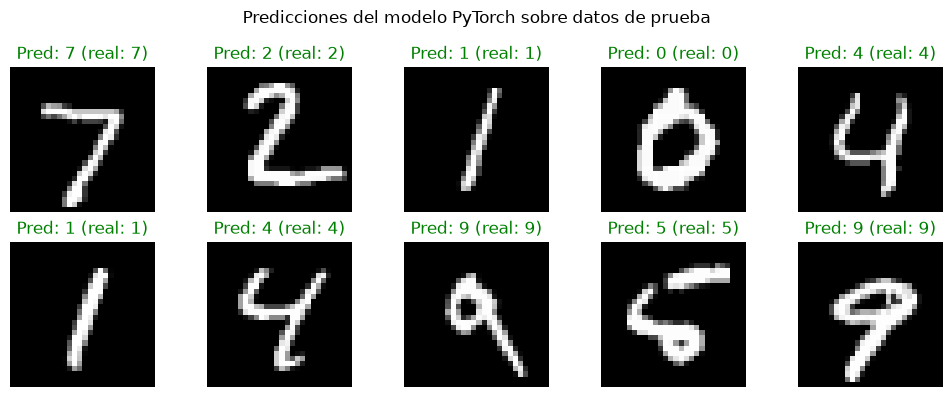

In [13]:
# Evidencia de ejecución: predicciones sobre algunas muestras de prueba
model_torch_mnist.eval()
with torch.no_grad():
    preds_torch = torch.argmax(model_torch_mnist(X_test_t[:10]), dim=1).numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap="gray")
    color = "green" if preds_torch[i] == y_test[i] else "red"
    ax.set_title(f"Pred: {preds_torch[i]} (real: {y_test[i]})", color=color)
    ax.axis("off")
plt.suptitle("Predicciones del modelo PyTorch sobre datos de prueba")
plt.tight_layout()
plt.show()

## 4. Comparación de resultados y evidencias de ejecución

In [14]:
print("Resumen de exactitud sobre el conjunto de prueba de MNIST\n")
print(f"{'Framework':<20}{'Arquitectura':<30}{'Accuracy (test)':>18}")
print("-" * 68)
print(f"{'TensorFlow/Keras':<20}{'784-128-64-10 (denso)':<30}{test_acc_keras*100:>17.2f}%")
print(f"{'PyTorch':<20}{'784-128-64-10 (denso)':<30}{test_acc_torch*100:>17.2f}%")

Resumen de exactitud sobre el conjunto de prueba de MNIST

Framework           Arquitectura                     Accuracy (test)
--------------------------------------------------------------------
TensorFlow/Keras    784-128-64-10 (denso)                     97.27%
PyTorch             784-128-64-10 (denso)                     97.68%


## 5. Conclusiones

- Pasar de clasificación binaria a clasificación multiclase implica un cambio de diseño importante: la salida ya no es una sola neurona con sigmoide, sino una neurona por clase (10, en este caso) con activación Softmax, que reparte la "confianza" del modelo entre todas las opciones posibles.
- Tanto Keras como PyTorch llegan a una exactitud muy alta sobre MNIST (por encima del 97%) usando solo capas densas, sin necesidad de redes convolucionales — aunque en la práctica una CNN suele hacerlo un poco mejor todavía, porque aprovecha la forma 2D de las imágenes; eso queda para otra ocasión, fuera del alcance de esta actividad.
- Keras resume casi todo el entrenamiento en una sola instrucción (`model.fit(...)`), mientras que en PyTorch hay que escribir el ciclo completo a mano: calcular la salida, medir el error, propagar el gradiente y actualizar los pesos. Es más código, pero también se ve con más claridad qué está pasando en cada paso.
- Un detalle técnico que vale la pena recordar: en PyTorch, `nn.CrossEntropyLoss` ya aplica Softmax por dentro, así que la red no lo hace explícitamente en su última capa — a diferencia de Keras, donde sí se declara `activation="softmax"` directamente en esa capa.
- En conjunto, este ejercicio muestra que las ideas de fondo (backpropagation, funciones de activación, descenso de gradiente) son las mismas sin importar el framework — lo que cambia es cómo se expresan en código, y ambos terminan dando resultados muy parecidos sobre el mismo problema.

## 6. Repositorio GitHub

Enlace del repositorio con este notebook: **https://github.com/JoanBeltranAlt/redes-neuronales-ii**
